# **Statistics for X-ray data analysis**

Contact: honghui.liu\<at\>uni-tuebingen.de

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson

In [16]:
%matplotlib inline
#set_matplotlib_formats('svg')
%config InlineBackend.figure_formats = ['svg']

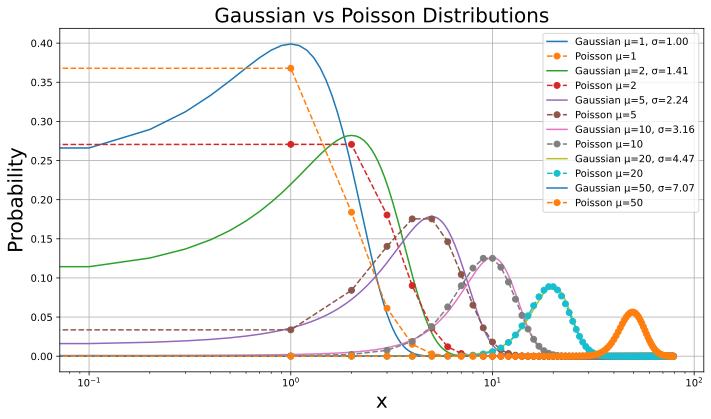

In [19]:
# Means to plot
means = [1, 2, 5, 10, 20, 50]

x = np.arange(0, 80, 0.1)  # x-range for Gaussian
x_p = np.arange(0, 80, 1)  # x-range for Poisson

plt.figure(figsize=(10, 6))

for mu in means:
    sigma = np.sqrt(mu)

    # Gaussian distribution
    gauss = norm.pdf(x, loc=mu, scale=sigma)
    plt.plot(x, gauss, label=f"Gaussian μ={mu}, σ={sigma:.2f}")

    # Poisson distribution
    pois = poisson.pmf(x_p, mu)
    plt.plot(x_p, pois, marker = "o", ls="--", label=f"Poisson μ={mu}")

plt.xscale("log")
plt.xlabel("x", fontsize=20)
plt.ylabel("Probability", fontsize=20)
plt.title("Gaussian vs Poisson Distributions", fontsize=20)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Normal distribution

$$
\mathcal{N}(x, \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}}
       \exp\!\left( -\,\frac{(x-\mu)^2}{2\sigma^2} \right)
$$

## Poisson distribution

$$
\mathcal{P}(k, \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad k = 0, 1, 2, \dots
$$

## Maximum likelihood approach

The likelihood of data $\{X_i\}$ (e.g., the counts in the $i$th channel) given a model $M(\theta)$ can be written as:

$$
\mathcal{L}(\{X_i\}, M(\theta)) = \prod_{i=1}^{N} \mathcal{P}(X_i, M_i (\theta))
$$

where $M_i(\theta)$ is the model predicted counts given parameter $\theta$ and $P(X_i, M_i (\theta))$ is the probability that the $i$th channel has count $X_i$ given a model-predicted value of $M_i$ calculated for parameter values $\theta$. In XSPEC: 

$$
M_i(\theta) = T \int \mathrm{RMF}(i, E) \times \mathrm{ARF}(E) \times S(\theta, E) dE
$$

### $\chi^2$ statistics

When the data noise is Gaussian:

$$
\begin{aligned}
\mathcal{L}(\{X_i\}) &= \prod_{i=1}^{N} \mathcal{N}(X_i, M_i, \sigma_i) \\
                     &= \prod_{i=1}^{N} \frac{1}{\sqrt{2 \pi}\sigma_i} \exp (-\frac{(X_i - M_i)^2}{2 \sigma^2})
\end{aligned}
$$

$$
\ln\mathcal{L}(\{X_i\}) = -\sum_{i=1}^{N}\frac{(X_i - M_i)^2}{2 \sigma_i^2} + \sum_{i=1}^{N} \ln \frac{1}{\sigma_i \sqrt{2 \pi}}
$$

$$
\begin{aligned}
-2 \ln\mathcal{L}(\{X_i\}) &= \sum_{i=1}^{N}\frac{(X_i - M_i)^2}{\sigma_i^2} - 2\sum_{i=1}^{N} \ln \frac{1}{\sigma_i \sqrt{2 \pi}} \\
                           &= S^2 - 2\sum_{i=1}^{N} \ln \frac{1}{\sigma_i \sqrt{2 \pi}}
\end{aligned}
$$

The second term is independent of the model. Therefore, maximizing $\mathcal{L}(\{X_i\})$ is equivalent minimizing the quantity:

$$
S^2 = \sum_{i=1}^{N}\frac{(X_i - M_i)^2}{\sigma_i^2}
$$

### $C$ statistics

Doing the same calculation for Poisson data gives:

$$
\ln\mathcal{L}(\{X_i\}) = -\sum_{i=1}^{N} (X_i \ln(M_i) - M_i - \ln(X_i !))
$$

The last term is independent of the model and to maximize the likelihood, one needs to minimize:

$$
C = 2 \sum_{i=1}^{N} (M_i - X_i \ln(M_i))
$$

This is the cash statistics. In XSPEC, the real statistics used is:

$$
\mathrm{Cstat} = 2 \sum_{i=1}^{N} (M_i - X_i + X_i\ln(Xi/M_i))
$$

which is obtained by replacing the term $\ln(X_i !)$ with the Stirling's approximation: $\ln(X_i !) = X_i \ln(X_i) - X_i$.

The $Cstat$ recovers to $S^2$ in the limit of large number of counts.

In XSPEC, $C$ statistics can be use by setting: `statistic cstat`.

**The choice of statistics depends on how the data are binned. For high counts data (e.g., counts per bin > 20), $\chi^2$ statistics can be used, which is default in XSPEC. For low count data, one should use  $C$ statistics.**

### Background

In the previous sections, it is assumed that the data $\{X_i\}$ come from only the source. In reality, there is background contribution. Therefore, the model predicted counts should be compared to the quantity $\{X_i\} - \{B_i\}$. There are a few cases to consider:

(1) Gaussian data with gaussian background.

(2) Poisson data with Poisson background.

(3) Poisson data with Gaussian background.

Check the XSPEC manual to see which statistic to use for each case.

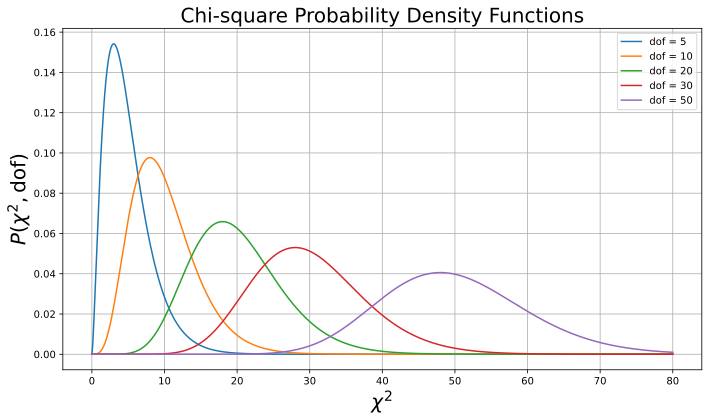

In [35]:
from scipy.stats import chi2

# Degrees of freedom to plot
dofs = [5, 10, 20, 30, 50]

# x range for chi-square distribution
x = np.linspace(0, 80, 1000)

plt.figure(figsize=(10, 6))

for k in dofs:
    pdf = chi2.pdf(x, k)
    plt.plot(x, pdf, label=f'dof = {k}')

plt.title("Chi-square Probability Density Functions", fontsize=20)
plt.xlabel(r'$\chi^2$', fontsize=20)
plt.ylabel(r"$P(\chi^2, \mathrm{dof})$", fontsize=20)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The expection value of $\chi^2$:

$$
\langle \chi^2 \rangle = \int_{0}^{\infty} \chi^2 \mathcal{P}(\chi^2, \mathrm{dof}) d\chi^2 = \mathrm{dof}
$$

For a good fit, one expected to reduced-$\chi^2$ ($\chi^2_\mathrm{red}$, $\chi^2/\mathrm{dof}$) to be $\sim$ 1. However this quanlity **should only be used as a rough estimation** for the goodness of the fit. The main reason is that the $\chi^2_\mathrm{red}$ has a variance of $\sigma \sim \sqrt{2/\mathrm{dof}}$ (see arXiv:1012.3754). Therefore, a  $\chi^2_\mathrm{red} = 1.1$ has very different meaning for dof of 10 and 10000.

It is suggested to check the `Null hypothesis probability` (i.e., the probability that the $\chi^2$ value would be at least as large as the observed χ² if the model were correct.), which is printed by XSPEC for each fitting.

### Confidence intervals

Once obtained the best-fit parameters from minimizing the statistics above, the next task the calculate the confidence bounds.

For $S^2$ statistics, the confidence intervals can be estimated by searching for parameter values such that:

$$
S^2(\alpha) = S^2_\mathrm{min} + \Delta(\nu, \alpha)
$$

where $\alpha$ is the significance level and ν the number of degrees of freedom. The same approximation holds for the $C$ statistic. The theory behind can be found in [Avni 1976](https://ui.adsabs.harvard.edu/abs/1976ApJ...210..642A/abstract) and [Cash 1979](https://ui.adsabs.harvard.edu/abs/1979ApJ...228..939C/abstract).

**Below is a table to check $\Delta(\nu, \alpha)$ given a degree of freedom and confidence level**

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

# Degrees of freedom
dfs = np.arange(1, 11)  # Change to 1..50 or 1..100 if you like

# Confidence levels (right-tail)
conf_levels = {
    "68% (p=0.32)" : 0.68,  # 68% confidence -> CDF = 0.68
    "90% (p=0.10)" : 0.90,
    "95% (p=0.05)" : 0.95,
    "99% (p=0.01)" : 0.99,
    "99.9% (p=0.001)" : 0.999
}

# Build table
data = {"dof": dfs}
for label, p in conf_levels.items():
    # chi2.ppf gives the critical value for CDF = p
    data[label] = [chi2.ppf(p, df) for df in dfs]

df_table = pd.DataFrame(data)

# Show nicely in Jupyter
df_table.style.format("{:.3f}")


,dof,68% (p=0.32),90% (p=0.10),95% (p=0.05),99% (p=0.01),99.9% (p=0.001)
0,1.000,0.989,2.706,3.841,6.635,10.828
1,2.000,2.279,4.605,5.991,9.210,13.816
2,3.000,3.506,6.251,7.815,11.345,16.266
3,4.000,4.695,7.779,9.488,13.277,18.467
4,5.000,5.861,9.236,11.070,15.086,20.515
5,6.000,7.009,10.645,12.592,16.812,22.458
6,7.000,8.145,12.017,14.067,18.475,24.322
7,8.000,9.270,13.362,15.507,20.090,26.124
8,9.000,10.388,14.684,16.919,21.666,27.877
9,10.000,11.499,15.987,18.307,23.209,29.588


## Sampling approach

The minimization/optimization algorithms can be stuck in local minima, especially when the parameter space is complex. In this case, one can run sampling algorithms to explore the parameter space. It is usually computationly more expensive than optimization algorithms.

### MCMC

An example in XSPEC:
```
>> chain walkers 100
>> chain length 1000 # e.g., 10 steps for each walker
>> chain burn 500
>> parallel walkers 60
>> chain run test.fits
```

### Bayesian

The BXA code: https://johannesbuchner.github.io/BXA/xspec-analysis.html

## Comparing model

Sometimes we need to decide which model fits better the data.

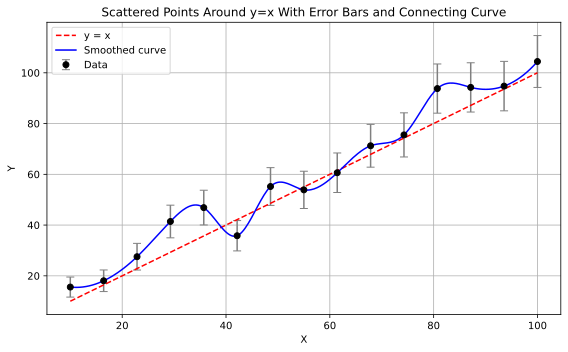

In [41]:
from scipy.interpolate import make_interp_spline

# -----------------------------
# Generate sample data
# -----------------------------
np.random.seed(0)

N = 15
x = np.linspace(10, 100, N)              # No overlap in X
#y = x + np.random.normal(0, 0.5, N)      # Scattered around y=x
sigma = np.sqrt(x)                     # Standard deviation = sqrt(x)
noise = np.random.normal(0, sigma) 
y = x + noise
#y_err = np.random.uniform(0.2, 0.5, N) # Error bars
y_err = np.sqrt(y)

# -----------------------------
# Build smooth curve
# -----------------------------
xs = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)     # Cubic spline interpolation
ys = spl(xs)

# -----------------------------
# Plotting
# -----------------------------
plt.figure(figsize=(8,5))

# Scatter with error bars
plt.errorbar(x, y, yerr=y_err, fmt='o', color='black',
             ecolor='gray', capsize=4, label='Data')

# Line y = x
plt.plot(xs, xs, 'r--', label='y = x')

# Smooth connecting curve
plt.plot(xs, ys, color='blue', label='Smoothed curve')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scattered Points Around y=x With Error Bars and Connecting Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Ftest

```
XSPEC> ftest chisq2 dof2 chisq1 dof1
```

Here `chisq2` and `dof2` are statistics and degrees of freedom of the complex model and `chisq1` and `dof1` are those of the simple model.

In [21]:
# A python code for ftest

from scipy.stats import f

def f_test(chi1, dof1, chi2, dof2):
    # F-statistic
    F = ((chi1 - chi2) / (dof1 - dof2)) / (chi2 / dof2)
    
    # p-value
    p = 1.0 - f.cdf(F, dof1 - dof2, dof2)
    return F, p

# Example
chi1 = 120.0
dof1 = 100
chi2 = 105.0
dof2 = 98

F, p = f_test(chi1, dof1, chi2, dof2)

print("F-statistic:", F)
print("p-value:", p)

F-statistic: 7.0
p-value: 0.0014401064585164436


The ftest can only be used when:

- **the simpler (null) model is nested within the other more complex (alternative) model, i.e. it is a subset of the complex model.**
- **the extra parameters of the alternative model have Gaussian (norm) distributions that are not truncated by parameter space boundaries.**

(Arnaud et al., "Handbook of X-ray astronomy")

*Question: Can the ftest be used to test if there is a emission/absorption line in the data? If not, how shall we do such a test?*


From the "Handbook of X-ray astronomy":

>Simulations and calculations of p-values1 are often the best approach to compare models. As an example, consider calculating p-values to test for the presence of an emission line: (1) fit the observed data with a simple (null) model; (2) fit the observed data with an alternative model and record the likelihood ratio (LR) between the alternative and null model fits; (3) generate a large number ( 500) of simulated data sets assuming the null model; (4) fit each simulated data set with the null and alternative model; (5) calculate the LR for each simulated data set; (6) make a histogram of the LRs and plot as shown in Figure 7.1; (7) compute the p-value, i.e. the probability of the observed LR given the distribution of LR in the simulations; (8) decide whether the null model is rejected or accepted. Usually a p-value < 0.05 would reject the null and accept the alternative model. In the simulations shown in the Figure below the null model would be selected and the evidence for a complex model rejected.

<img src="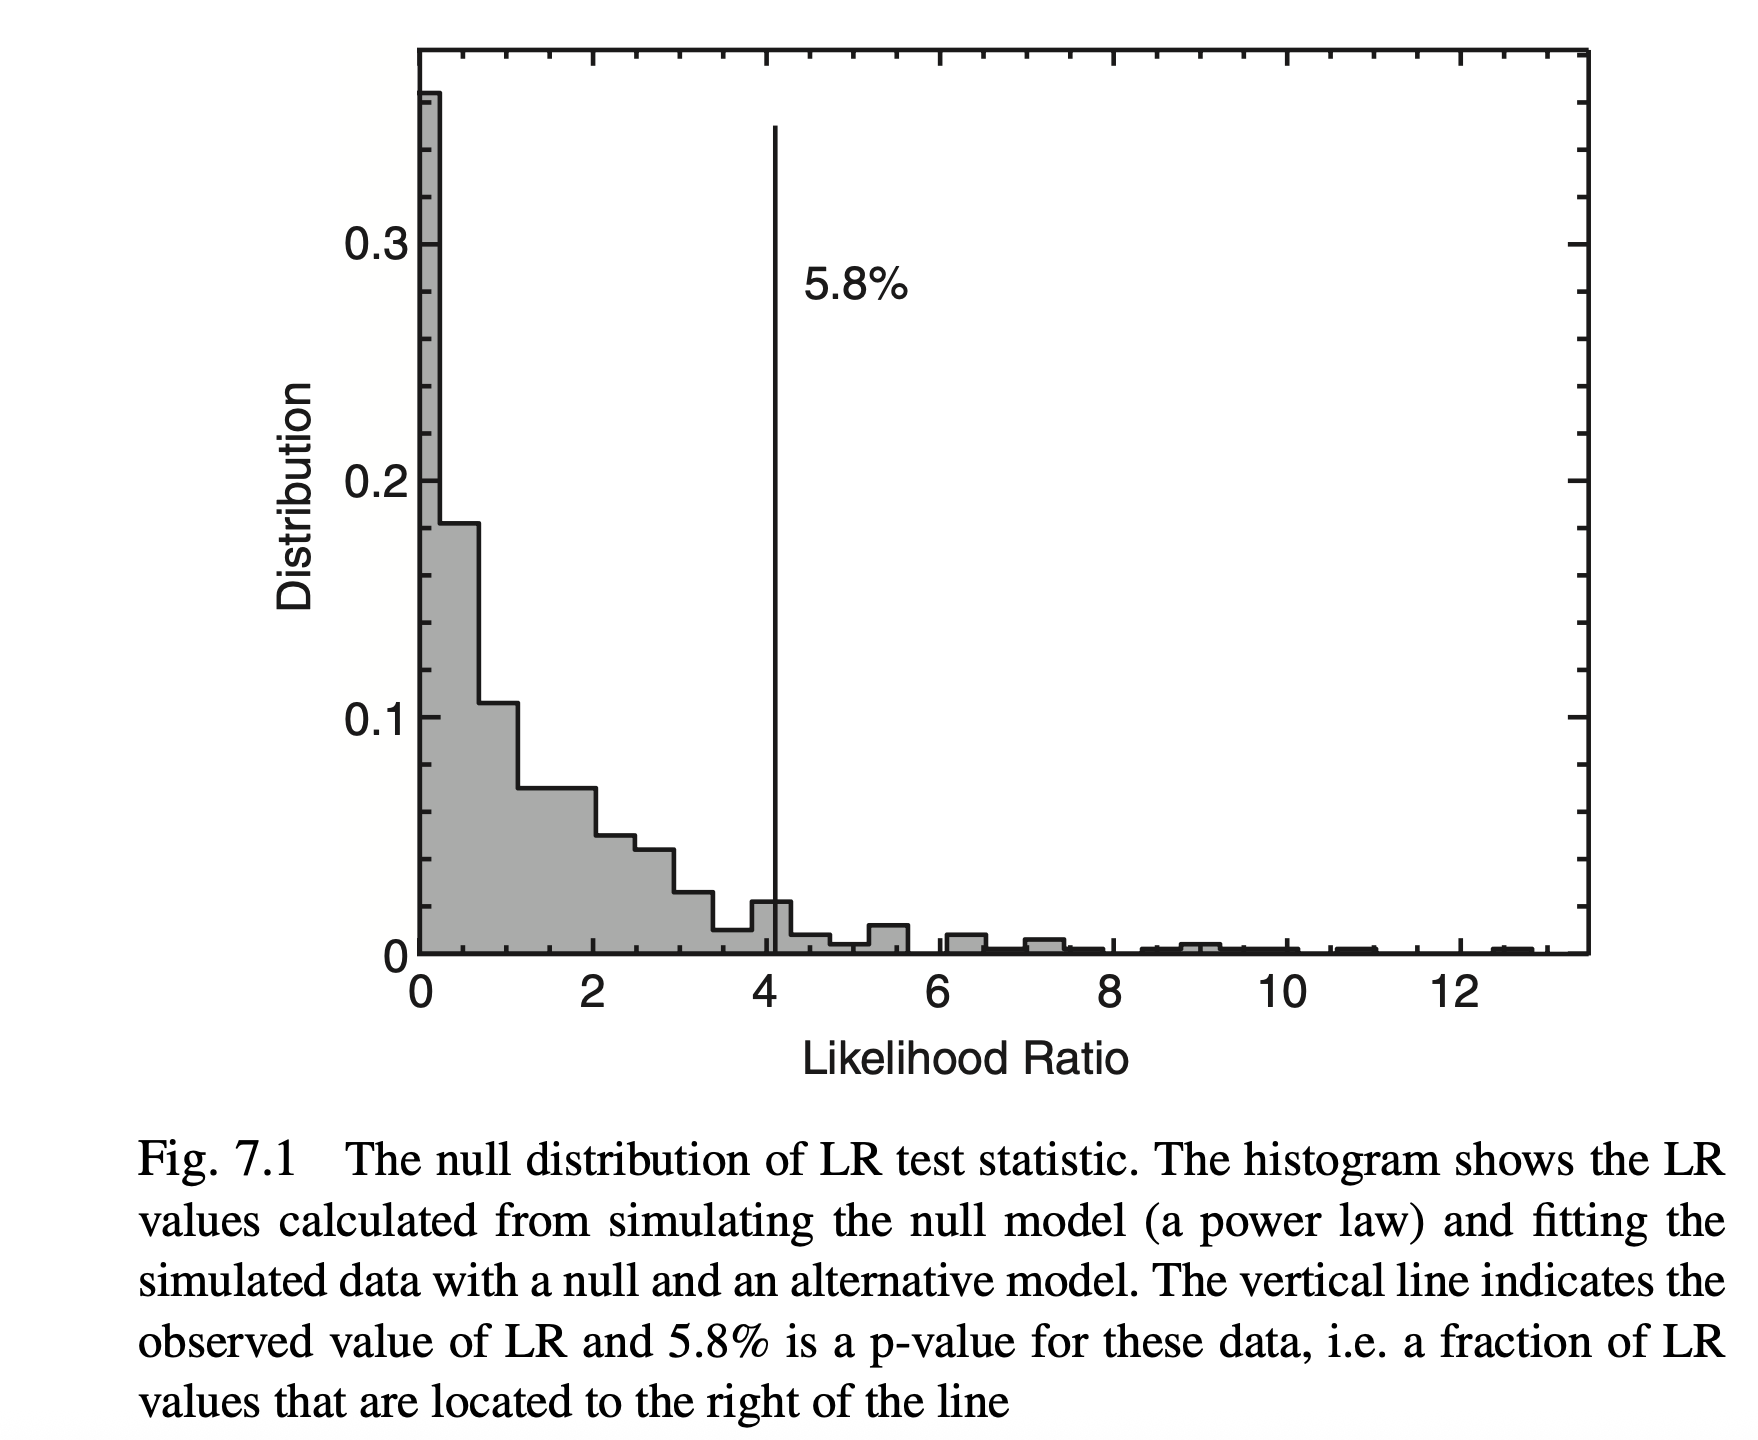
" alt="My plot" width="800"/>

**A figure adapted from the book "Handbook of X-ray astronomy"**

Information criteria: [Liddle 2007](https://arxiv.org/abs/astro-ph/0701113)

### Akaike Information Criterion (AIC)

$$
\mathrm{AIC} = -2 \ln \mathcal{L}  + 2 k
$$

Where $\mathcal{L}$ maximum likelihood and $k$ is the number of free parameters.

A lower AIC value indicates a better model. Differences $<4$ suggest models are equally good. Values $>10$ suggest the higher AIC model should be rejected.

If the sample size is small ($n/k < 40$), a corrected AIC should be used:

$$
\mathrm{AICc} = \mathrm{AIC} + \frac{2k(k+1)}{n-k-1}
$$

where $n$ is the number of data bins.

### Bayesian information criterion (BIC)

$$
\mathrm{BIC} = - 2 \ln (\mathcal{L}) + k \ln (n) 
$$

where $k$ is the number of free parameters, $n$ is the number of data points.

### Bayesian evidence